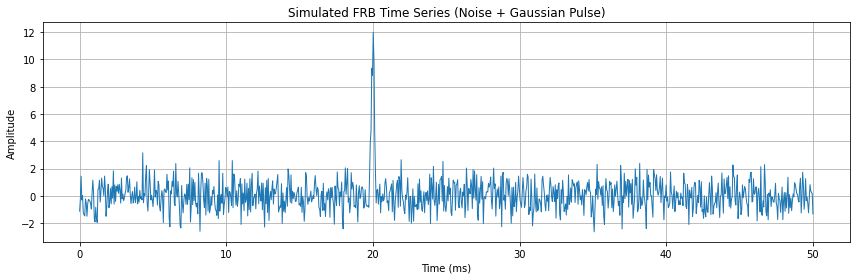

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 50, 1000) 

noise = np.random.normal(0, 1, size=t.size)

# FRB-like pulse: Gaussian peak
pulse_center = 20      # ms
pulse_width = 0.1      # ms
pulse_amplitude = 10   # Jy (arbitrary)

pulse = pulse_amplitude * np.exp(-(t - pulse_center)**2 / (2 * pulse_width**2))

# Combined signal
signal = noise + pulse

# Plot
plt.figure(figsize=(12,4))
plt.plot(t, signal, linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Simulated FRB Time Series (Noise + Gaussian Pulse)")
plt.tight_layout()
plt.grid()
plt.show()


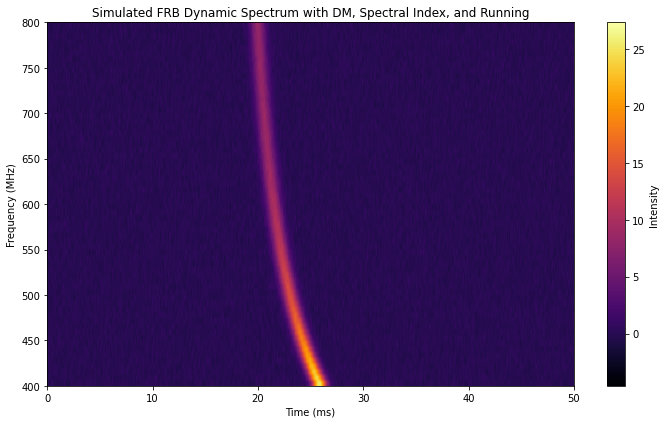

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Time and frequency axes
# -----------------------------
t = np.linspace(0, 50, 5000)          # ms
freqs = np.linspace(400, 800, 64)     # MHz

dynamic_spectrum = np.zeros((len(freqs), len(t)))

# -----------------------------
# 2. White noise
# -----------------------------
noise_level = 1.0
noise = np.random.normal(0, noise_level, size=dynamic_spectrum.shape)

# -----------------------------
# 3. FRB pulse in time (Gaussian)
# -----------------------------
pulse_width = 0.5      # ms
pulse_amplitude = 10   # arbitrary units

# -----------------------------
# 4. Dispersion Measure (DM)
# -----------------------------
DM = 300000  # pc/cm^3 (example)
nu_ref = freqs.max()  # reference frequency for zero delay

# Dispersion delay formula
delay_ms = 4.15 * DM * (freqs**-2 - nu_ref**-2)

# -----------------------------
# 5. Spectral index γ
# -----------------------------
gamma = -1.5
spec_index_shape = (freqs / freqs.mean()) ** gamma

# -----------------------------
# 6. Spectral running r
# -----------------------------
r = 0.004
gamma0 = gamma
gamma_freq = gamma0 + r * (freqs - freqs.mean())
spec_running_shape = (freqs / freqs.mean()) ** gamma_freq

# -----------------------------
# 7. Build dynamic spectrum
# -----------------------------
for i, f in enumerate(freqs):

    # Time-shifted pulse due to dispersion
    pulse_center = 20 + delay_ms[i]  # ms
    pulse_time = pulse_amplitude * np.exp(-(t - pulse_center)**2 / (2 * pulse_width**2))

    # Apply spectral shape
    spectrum_factor = spec_running_shape[i]

    dynamic_spectrum[i] = noise[i] + pulse_time * spectrum_factor

# -----------------------------
# 8. Plot the dynamic spectrum
# -----------------------------
plt.figure(figsize=(10, 6))
plt.imshow(dynamic_spectrum, aspect='auto', origin='lower',
           extent=[t.min(), t.max(), freqs.min(), freqs.max()],
           cmap='inferno')

plt.colorbar(label="Intensity")
plt.xlabel("Time (ms)")
plt.ylabel("Frequency (MHz)")
plt.title("Simulated FRB Dynamic Spectrum with DM, Spectral Index, and Running")
plt.tight_layout()
plt.show()


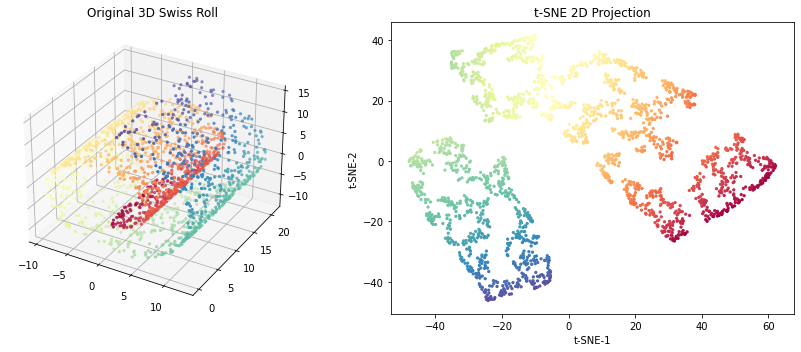

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE

# -----------------------------
# 1. Create a high‑dimensional dataset
# -----------------------------
X, color = make_swiss_roll(n_samples=2000, noise=0.05)

# -----------------------------
# 2. Apply t‑SNE (works everywhere)
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='random'
)

X_tsne = tsne.fit_transform(X)

# -----------------------------
# 3. Plot the original 3D manifold
# -----------------------------
fig = plt.figure(figsize=(12,5))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=color, cmap='Spectral', s=5)
ax.set_title("Original 3D Swiss Roll")

# -----------------------------
# 4. Plot the 2D t‑SNE embedding
# -----------------------------
plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=color, cmap='Spectral', s=5)
plt.title("t‑SNE 2D Projection")
plt.xlabel("t‑SNE‑1")
plt.ylabel("t‑SNE‑2")

plt.tight_layout()
plt.show()


/tmp/ipykernel_161637/3243128230.py:15: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(sq[:,None] + sq[None,:] - 2*A.dot(A.T))


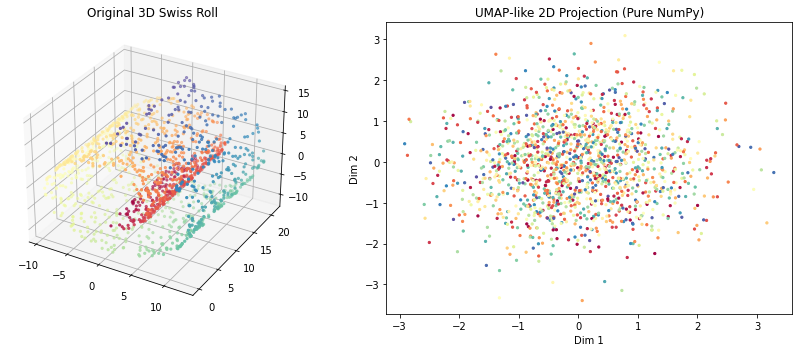

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

# -----------------------------
# 1. Create dataset
# -----------------------------
X, color = make_swiss_roll(n_samples=1500, noise=0.05)

# -----------------------------
# 2. Compute pairwise distances
# -----------------------------
def pairwise_distances(A):
    sq = np.sum(A**2, axis=1)
    return np.sqrt(sq[:,None] + sq[None,:] - 2*A.dot(A.T))

D = pairwise_distances(X)

# -----------------------------
# 3. Build k‑NN graph
# -----------------------------
k = 15
knn_idx = np.argsort(D, axis=1)[:, 1:k+1]
knn_dist = np.take_along_axis(D, knn_idx, axis=1)

# -----------------------------
# 4. Convert distances to similarities
#    (UMAP uses fuzzy sets; we use a simple exponential kernel)
# -----------------------------
sigma = np.mean(knn_dist)
W = np.exp(-D / sigma)

# -----------------------------
# 5. Initialize 2D embedding
# -----------------------------
Y = np.random.normal(0, 1, (X.shape[0], 2))

# -----------------------------
# 6. Optimize embedding (simple gradient descent)
# -----------------------------
lr = 0.01
def pairwise_distances(A):
    sq = np.sum(A**2, axis=1)
    D2 = sq[:,None] + sq[None,:] - 2*A.dot(A.T)
    D2 = np.maximum(D2, 0)   # prevent tiny negative values
    return np.sqrt(D2)

# -----------------------------
# 7. Plot result
# -----------------------------
plt.figure(figsize=(12,5))

# Original 3D
ax = plt.subplot(1,2,1, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=color, cmap='Spectral', s=5)
ax.set_title("Original 3D Swiss Roll")

# 2D embedding
plt.subplot(1,2,2)
plt.scatter(Y[:,0], Y[:,1], c=color, cmap='Spectral', s=5)
plt.title("UMAP‑like 2D Projection (Pure NumPy)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.tight_layout()
plt.show()

